# PyTorch CNN for MNIST Classification
## Complete Training Pipeline with Callbacks, Evaluation & Inference

This notebook demonstrates:
- CNN model architecture for MNIST
- Training with callbacks (early stopping, model checkpointing)
- Comprehensive evaluation with plots
- Model saving and loading for inference

## 1. Import Libraries and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
import time

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## 2. Data Loading and Preprocessing

You can use `torchvision.datasets.ImageFolder` to load custom image data organized in folders (one folder per class) and then wrap it with a `DataLoader`. Here’s how you can do it:



In [8]:
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader

# # Define transforms (customize as needed)
# transform = transforms.Compose([
#     transforms.Resize((28, 28)),      # Resize images to 28x28
#     transforms.Grayscale(num_output_channels=1),  # Convert to grayscale if needed
#     transforms.ToTensor(),            # Convert to tensor
#     transforms.Normalize((0.5,), (0.5,)) # Normalize (adjust mean/std as needed)
# ])

# # Load dataset from 'data/' directory
# dataset = datasets.ImageFolder(root='data/', transform=transform)

# # Create DataLoader
# batch_size = 64
# data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# # Show class names
# print("Classes:", dataset.classes)
# print("Number of samples:", len(dataset))

## If the Images Names and labels in CSV file, then 

```python
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0]  # First column: image filename
        label = self.data.iloc[idx, 1]     # Second column: label
        img_path = f"{self.img_dir}/{img_name}"
        image = Image.open(img_path).convert("L")  # Convert to grayscale if needed
        if self.transform:
            image = self.transform(image)
        return image, int(label)

# Usage
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = CustomImageDataset(csv_file='labels.csv', img_dir='images', transform=transform)
data_loader = DataLoader(dataset, batch_size=64, shuffle=True)
```



**Folder structure should be:**


In [ ]:
data/
  class1/
    img1.png
    img2.png
    ...
  class2/
    img1.png
    ...
  ...



This will automatically assign labels based on folder names and load images for training.

In [2]:
# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load datasets
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Batch size: {batch_size}')
print(f'Training batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 97.2kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 347kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.40MB/s]


Training samples: 60000
Test samples: 10000
Batch size: 128
Training batches: 469
Test batches: 79


## 3. Visualize Random Training Images

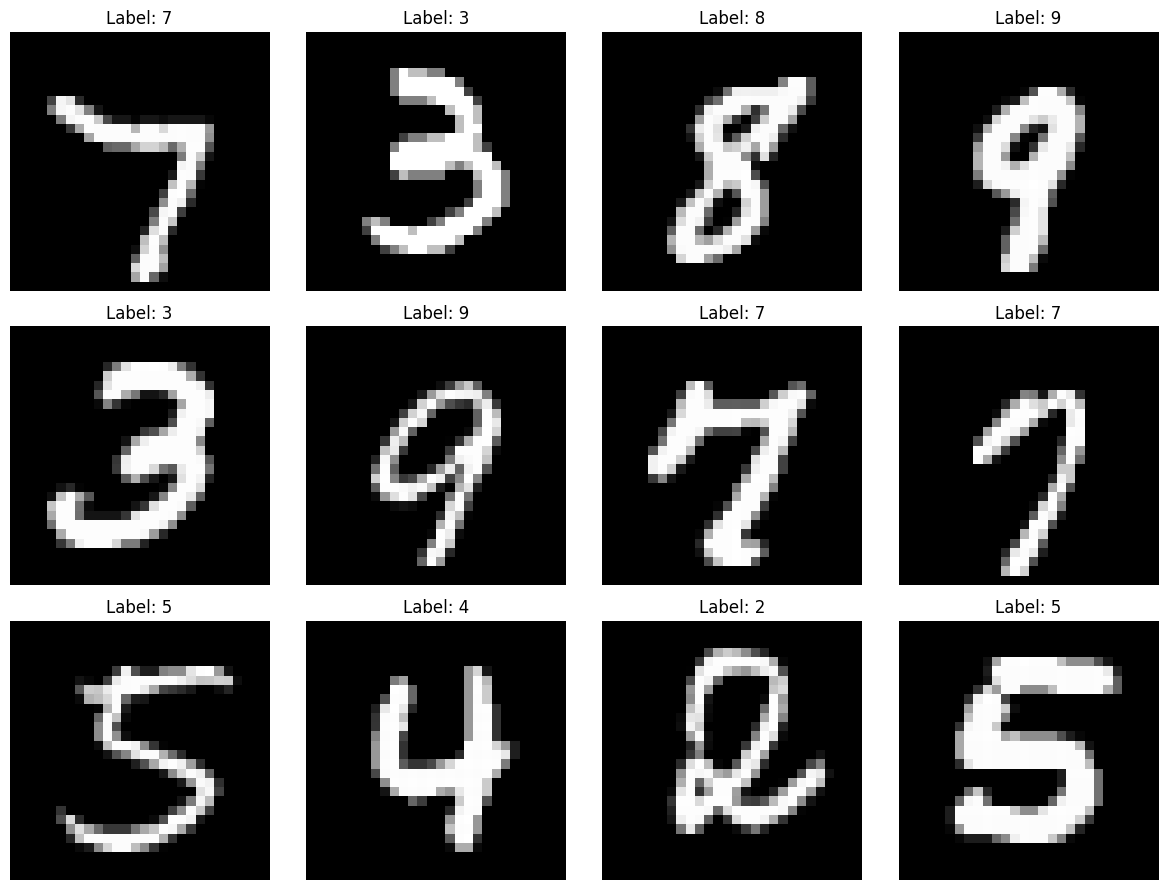

In [3]:
# Function to show random images
def show_random_images(dataset, num_images=12):
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.ravel()
    
    # Get random indices
    indices = np.random.choice(len(dataset), num_images, replace=False)
    
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        # Convert tensor to numpy and remove channel dimension
        image = image.squeeze().numpy()
        
        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show random training images
show_random_images(train_dataset)

## 4. CNN Model Architecture

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)
        
    def forward(self, x):
        # Conv block 1
        x = self.pool(F.relu(self.conv1(x)))
        
        # Conv block 2
        x = self.pool(F.relu(self.conv2(x)))
        
        # Conv block 3
        x = self.pool(F.relu(self.conv3(x)))
        x = self.dropout1(x)
        
        # Flatten
        x = x.view(-1, 128 * 3 * 3)
        
        # FC layers
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        
        return x

# Initialize model
model = CNN().to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 390,410
Trainable parameters: 390,410


## 5. Training Setup with Callbacks

In [5]:
# Training configuration
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Callback classes
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

class ModelCheckpoint:
    def __init__(self, filepath, monitor='val_loss', save_best_only=True):
        self.filepath = filepath
        self.monitor = monitor
        self.save_best_only = save_best_only
        self.best_score = float('inf') if 'loss' in monitor else 0
        
    def __call__(self, model, score):
        if self.save_best_only:
            if ('loss' in self.monitor and score < self.best_score) or \
               ('acc' in self.monitor and score > self.best_score):
                self.best_score = score
                torch.save(model.state_dict(), self.filepath)
                print(f'Model saved with {self.monitor}: {score:.4f}')
        else:
            torch.save(model.state_dict(), self.filepath)

# Initialize callbacks
early_stopping = EarlyStopping(patience=7, min_delta=0.001)
model_checkpoint = ModelCheckpoint('best_model.pth', monitor='val_loss')

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

## 6. Training and Validation Functions

In [6]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

## 7. Training Loop with Callbacks

In [7]:
# Training parameters
num_epochs = 2
start_time = time.time()

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validation
    val_loss, val_acc = validate_epoch(model, test_loader, criterion, device)
    
    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Callbacks
    model_checkpoint(model, val_loss)
    
    epoch_time = time.time() - epoch_start
    
    print(f'Epoch [{epoch+1:2d}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% '
          f'Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}% '
          f'LR: {current_lr:.6f} Time: {epoch_time:.1f}s')
    
    # Early stopping
    if early_stopping(val_loss):
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

total_time = time.time() - start_time
print("-" * 60)
print(f'Training completed in {total_time:.1f}s')

# Save final model
torch.save(model.state_dict(), 'final_model.pth')
print('Final model saved as final_model.pth')

Starting training...
------------------------------------------------------------
Model saved with val_loss: 0.0465
Epoch [ 1/2] Train Loss: 0.2426 Train Acc: 92.33% Val Loss: 0.0465 Val Acc: 98.32% LR: 0.001000 Time: 56.3s
Model saved with val_loss: 0.0273
Epoch [ 2/2] Train Loss: 0.0682 Train Acc: 97.96% Val Loss: 0.0273 Val Acc: 99.05% LR: 0.001000 Time: 66.2s
------------------------------------------------------------
Training completed in 122.5s
Final model saved as final_model.pth


## 8. Training History Visualization

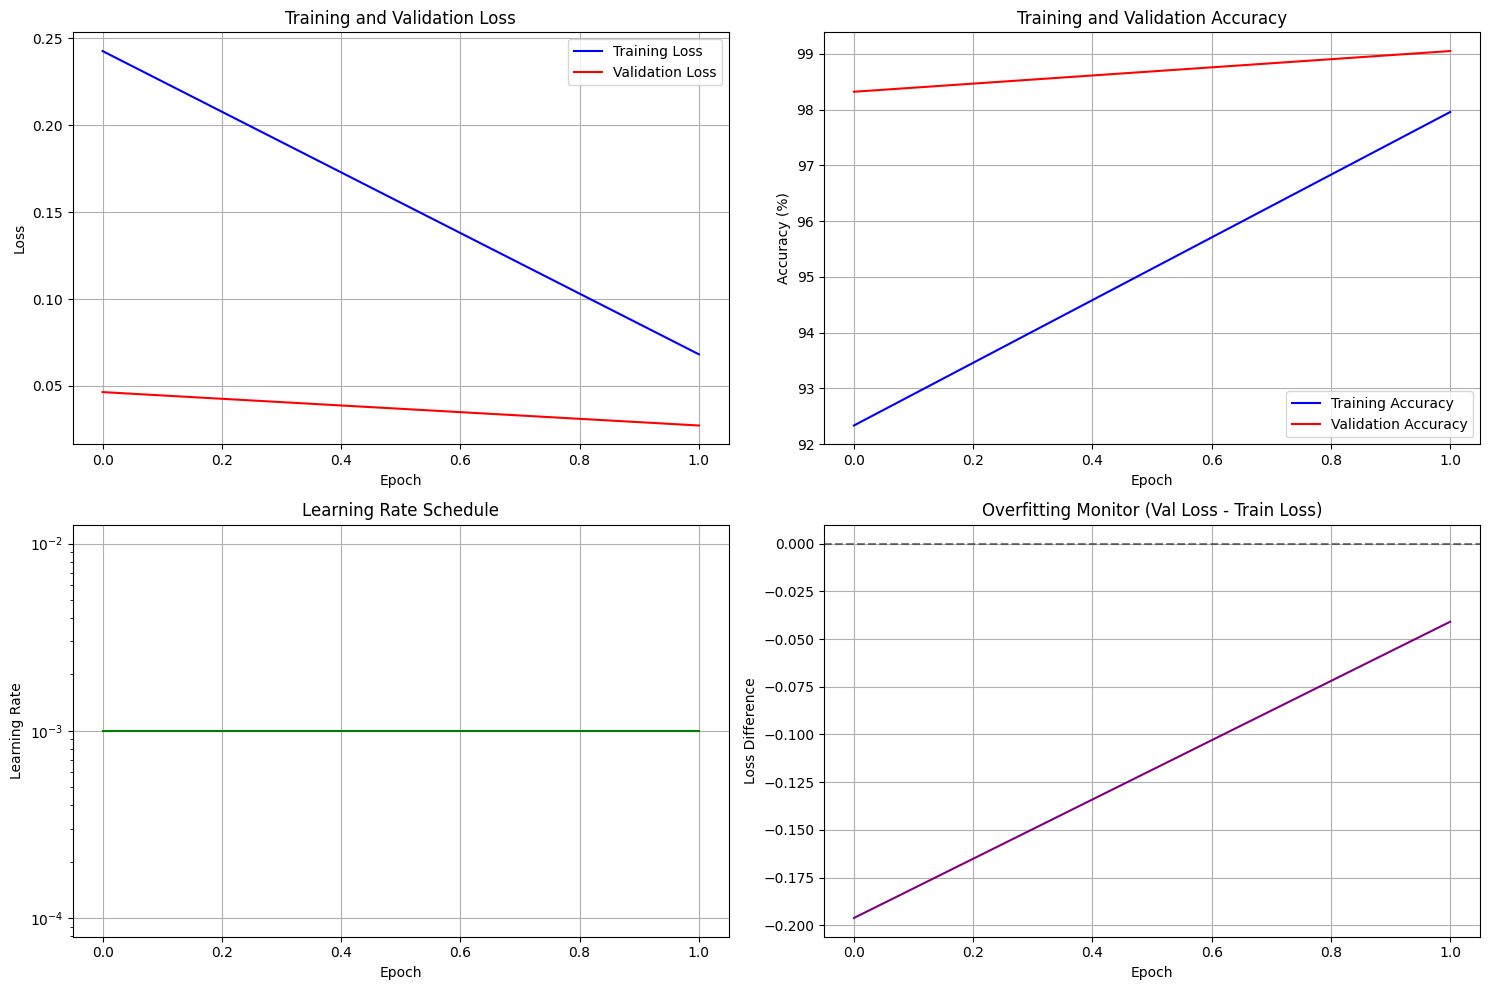

Final Training Accuracy: 97.96%
Final Validation Accuracy: 99.05%
Best Validation Accuracy: 99.05%
Final Training Loss: 0.0682
Final Validation Loss: 0.0273


In [9]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Training Loss', color='blue')
axes[0, 0].plot(history['val_loss'], label='Validation Loss', color='red')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy curves
axes[0, 1].plot(history['train_acc'], label='Training Accuracy', color='blue')
axes[0, 1].plot(history['val_acc'], label='Validation Accuracy', color='red')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Learning rate
axes[1, 0].plot(history['lr'], color='green')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True)

# Loss difference
loss_diff = np.array(history['val_loss']) - np.array(history['train_loss'])
axes[1, 1].plot(loss_diff, color='purple')
axes[1, 1].set_title('Overfitting Monitor (Val Loss - Train Loss)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss Difference')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"Final Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"Best Validation Accuracy: {max(history['val_acc']):.2f}%")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")

## 9. Model Evaluation - Confusion Matrix

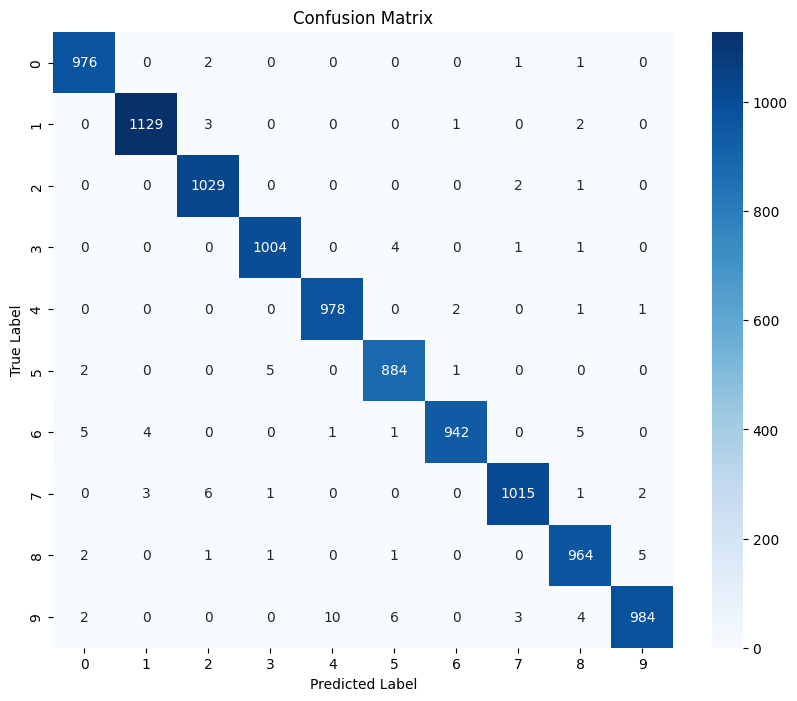

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [10]:
# Load best model for evaluation
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Get predictions for test set
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = F.softmax(output, dim=1)
        _, predicted = torch.max(output, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(target.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

## 10. ROC Curves and AUC Scores

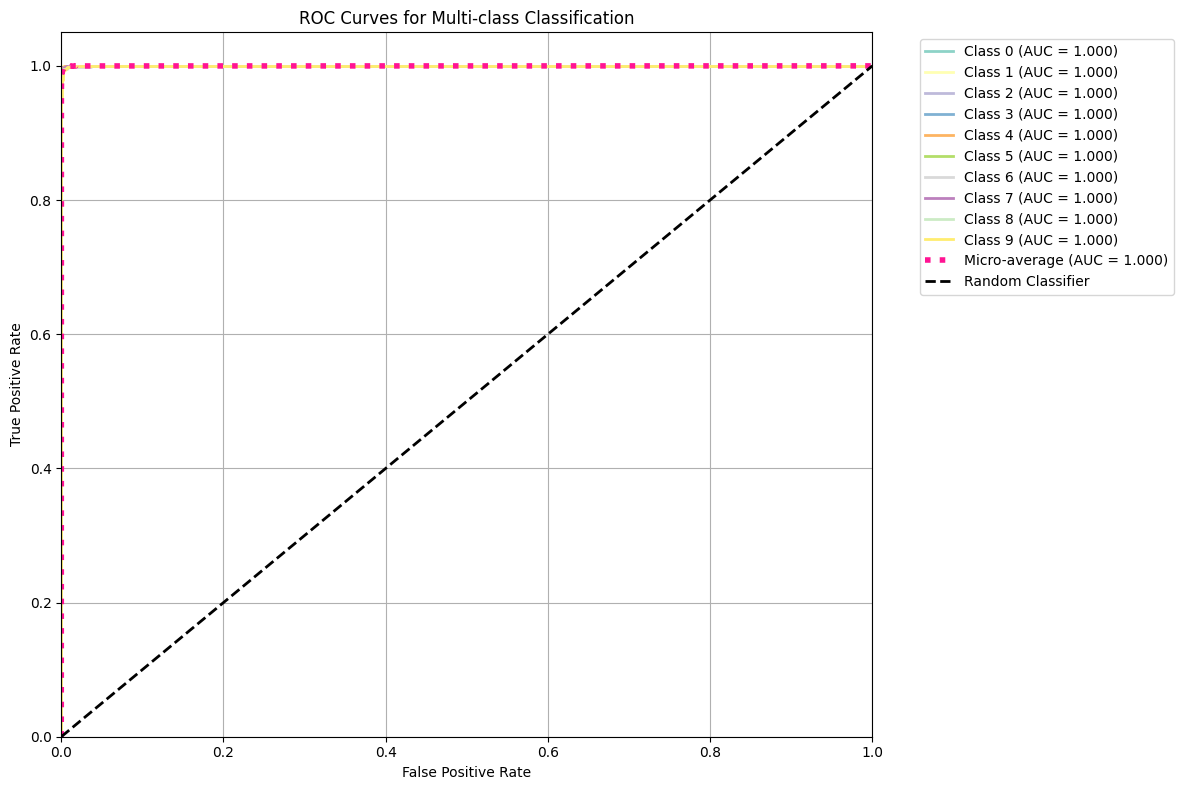

AUC Scores by Class:
Class 0: 1.0000
Class 1: 1.0000
Class 2: 1.0000
Class 3: 1.0000
Class 4: 1.0000
Class 5: 0.9999
Class 6: 0.9999
Class 7: 1.0000
Class 8: 0.9999
Class 9: 0.9999

Micro-average AUC: 0.9999
Macro-average AUC: 1.0000


In [11]:
# Binarize labels for multiclass ROC
y_test_bin = label_binarize(all_labels, classes=range(10))
n_classes = 10

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(12, 8))

# Plot ROC curve for each class
colors = plt.cm.Set3(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-class Classification')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print AUC scores
print("AUC Scores by Class:")
for i in range(n_classes):
    print(f"Class {i}: {roc_auc[i]:.4f}")
print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")
print(f"Macro-average AUC: {np.mean([roc_auc[i] for i in range(n_classes)]):.4f}")

## 11. Per-Class Performance Analysis

Per-Class Performance Metrics:
   Class  Precision  Recall  F1-Score     AUC  Support
0      0     0.9889  0.9959    0.9924  1.0000      980
1      1     0.9938  0.9947    0.9943  1.0000     1135
2      2     0.9885  0.9971    0.9928  1.0000     1032
3      3     0.9931  0.9941    0.9936  1.0000     1010
4      4     0.9889  0.9959    0.9924  1.0000      982
5      5     0.9866  0.9910    0.9888  0.9999      892
6      6     0.9958  0.9833    0.9895  0.9999      958
7      7     0.9932  0.9874    0.9902  1.0000     1028
8      8     0.9837  0.9897    0.9867  0.9999      974
9      9     0.9919  0.9752    0.9835  0.9999     1009


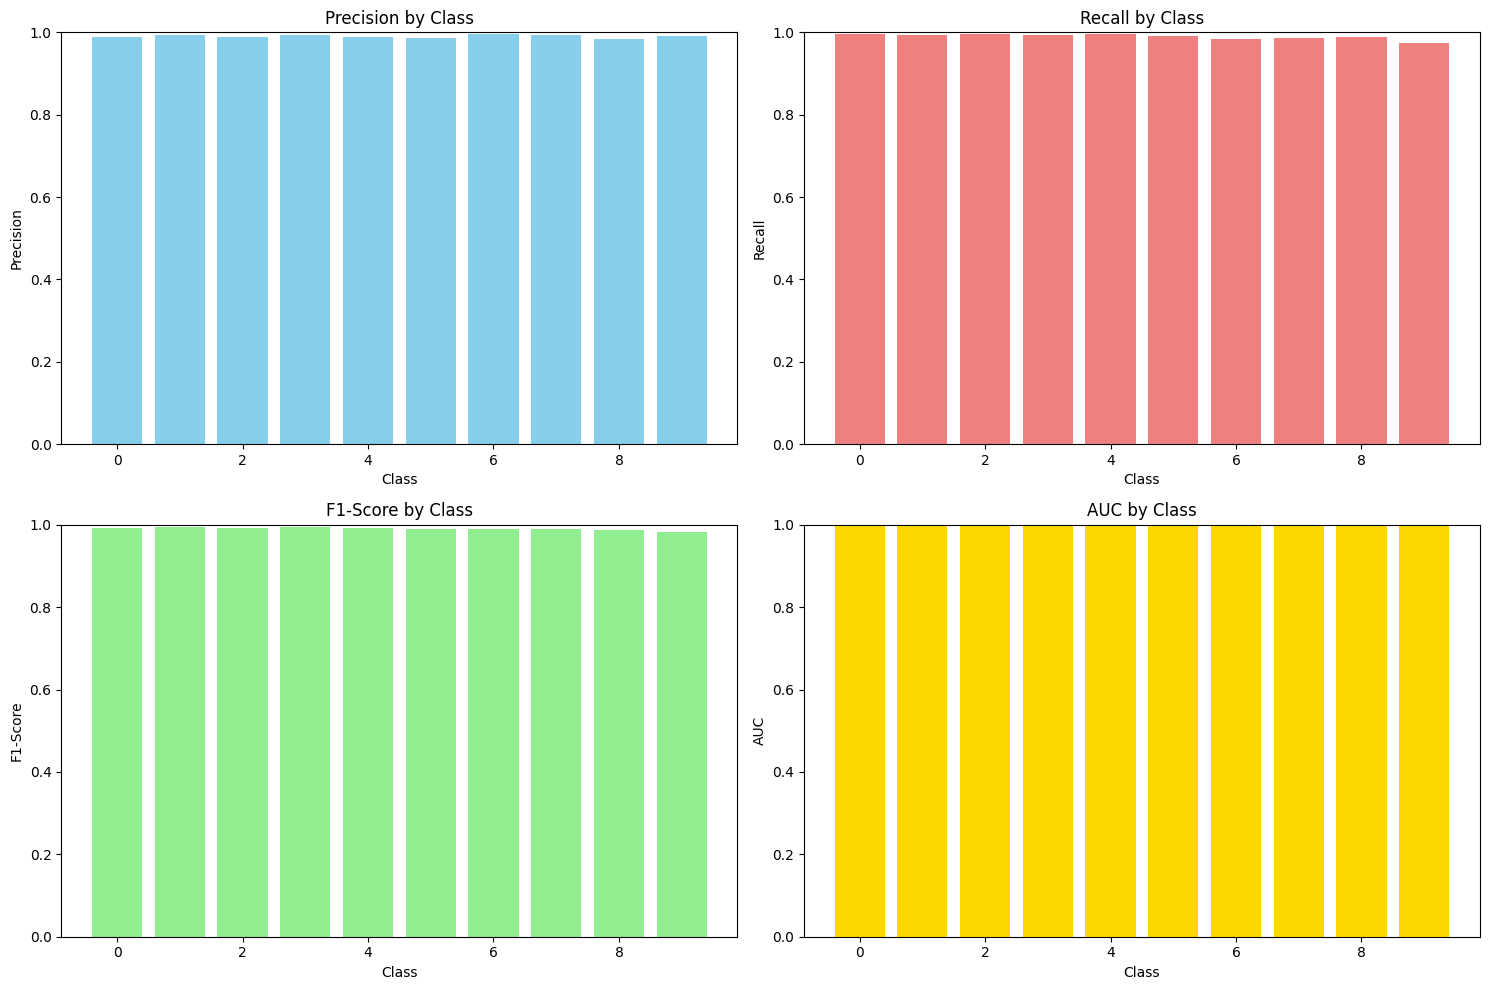


Overall Test Accuracy: 0.9905 (99.05%)


In [12]:
# Calculate per-class metrics
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds)

# Create performance dataframe
import pandas as pd

performance_df = pd.DataFrame({
    'Class': range(10),
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'AUC': [roc_auc[i] for i in range(10)],
    'Support': support
})

print("Per-Class Performance Metrics:")
print(performance_df.round(4))

# Visualize per-class performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Precision by class
axes[0, 0].bar(range(10), precision, color='skyblue')
axes[0, 0].set_title('Precision by Class')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_ylim([0, 1])

# Recall by class
axes[0, 1].bar(range(10), recall, color='lightcoral')
axes[0, 1].set_title('Recall by Class')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].set_ylim([0, 1])

# F1-Score by class
axes[1, 0].bar(range(10), f1, color='lightgreen')
axes[1, 0].set_title('F1-Score by Class')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_ylim([0, 1])

# AUC by class
auc_scores = [roc_auc[i] for i in range(10)]
axes[1, 1].bar(range(10), auc_scores, color='gold')
axes[1, 1].set_title('AUC by Class')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Overall accuracy
overall_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")

## 12. Model Inference - Loading and Testing

Model loaded successfully for inference!


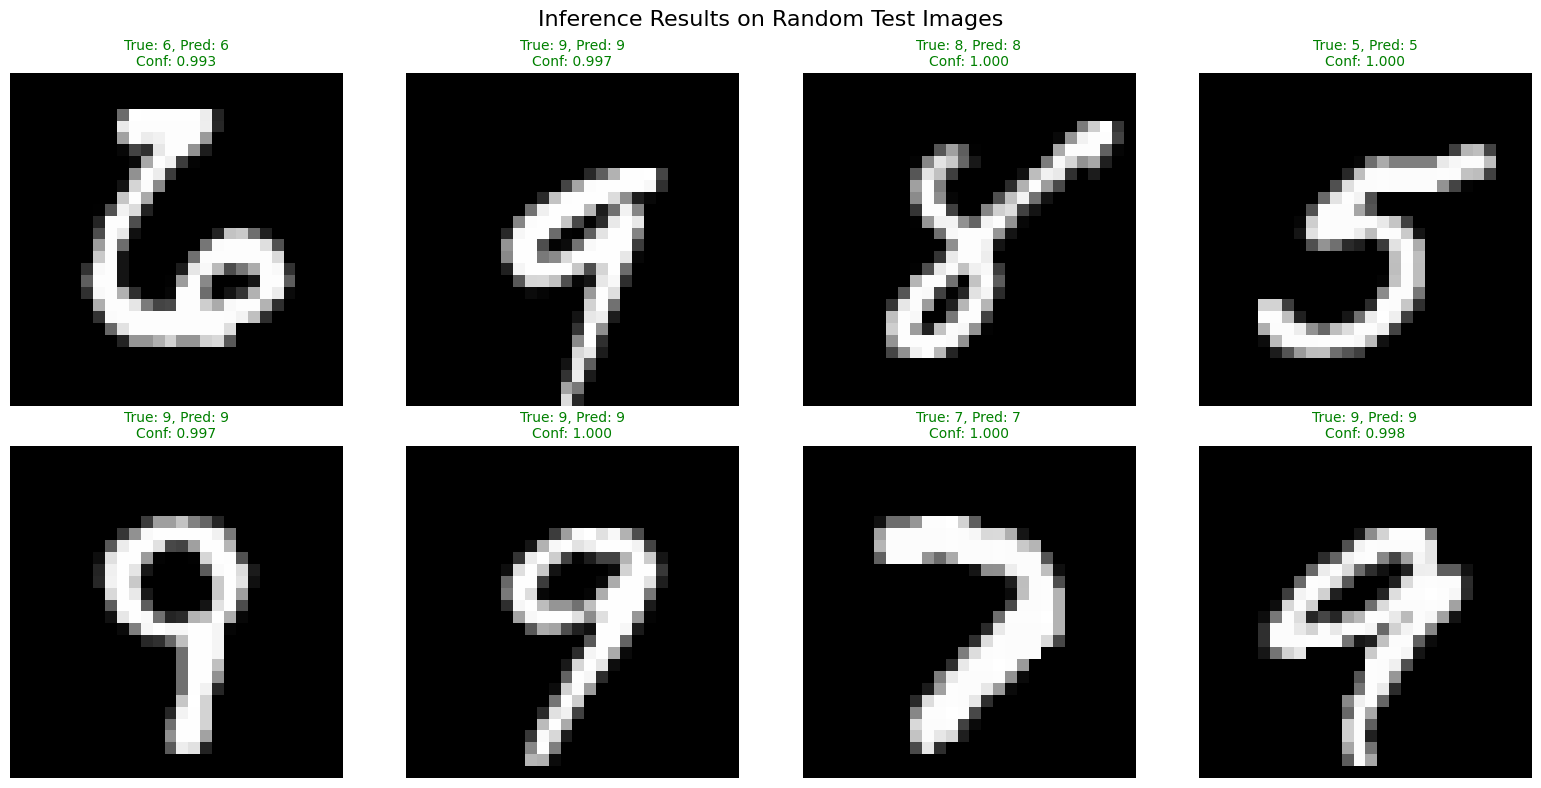

In [13]:
# Create a new model instance for inference
inference_model = CNN().to(device)

# Load the best saved model
inference_model.load_state_dict(torch.load('best_model.pth'))
inference_model.eval()

print("Model loaded successfully for inference!")

# Function for single image prediction
def predict_single_image(model, image_tensor, device):
    """Predict a single image"""
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)  # Add batch dimension
        output = model(image_tensor)
        probabilities = F.softmax(output, dim=1)
        predicted_class = torch.argmax(output, dim=1).item()
        confidence = probabilities[0][predicted_class].item()
    return predicted_class, confidence, probabilities[0].cpu().numpy()

# Test inference on random test images
def test_inference(model, test_dataset, num_samples=8):
    """Test inference on random samples"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    # Get random test samples
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        image, true_label = test_dataset[idx]
        
        # Make prediction
        pred_class, confidence, probs = predict_single_image(model, image, device)
        
        # Display image
        axes[i].imshow(image.squeeze().numpy(), cmap='gray')
        
        # Set title with prediction info
        color = 'green' if pred_class == true_label else 'red'
        axes[i].set_title(f'True: {true_label}, Pred: {pred_class}\nConf: {confidence:.3f}', 
                         color=color, fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle('Inference Results on Random Test Images', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return indices

# Run inference test
test_indices = test_inference(inference_model, test_dataset)

## 13. Detailed Prediction Analysis

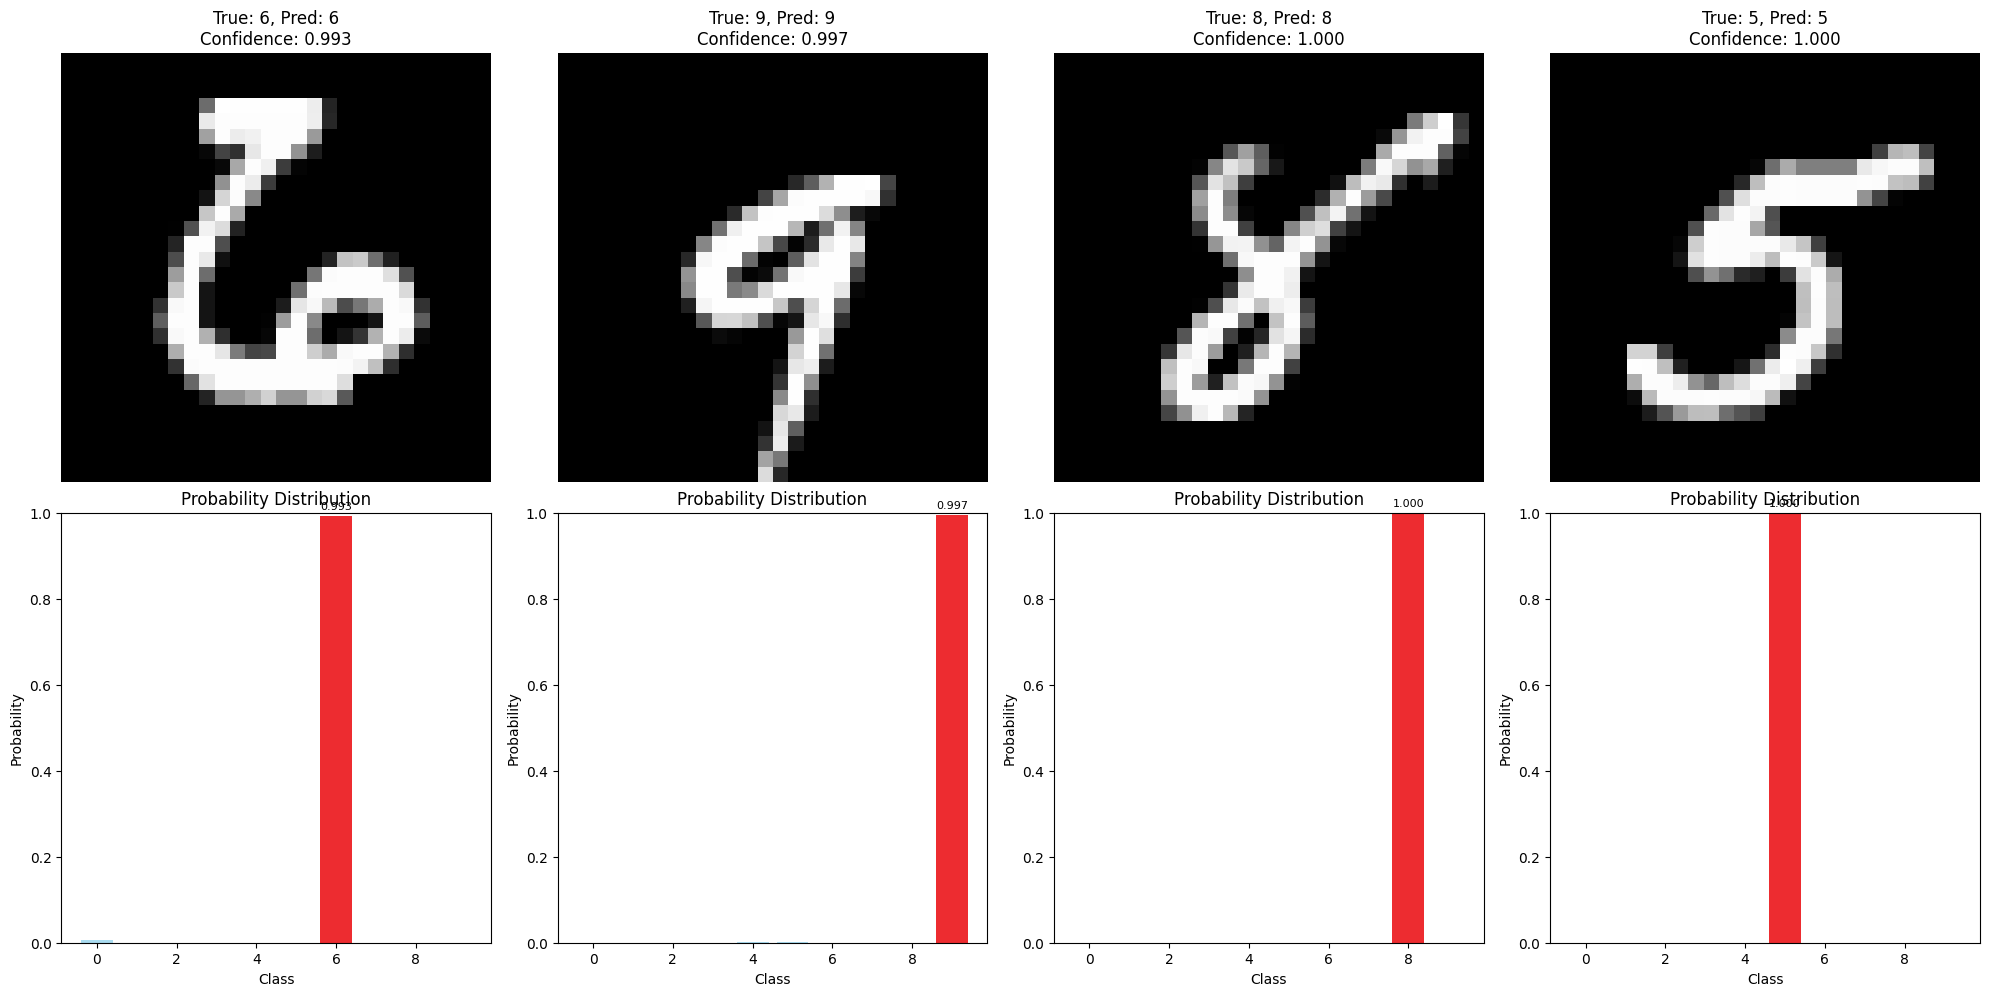

In [14]:
# Analyze predictions in detail for a few samples
def analyze_predictions(model, test_dataset, indices):
    """Detailed analysis of predictions"""
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for i, idx in enumerate(indices[:4]):
        image, true_label = test_dataset[idx]
        pred_class, confidence, probs = predict_single_image(model, image, device)
        
        # Show image
        axes[0, i].imshow(image.squeeze().numpy(), cmap='gray')
        axes[0, i].set_title(f'True: {true_label}, Pred: {pred_class}\nConfidence: {confidence:.3f}')
        axes[0, i].axis('off')
        
        # Show probability distribution
        axes[1, i].bar(range(10), probs, color='skyblue', alpha=0.7)
        axes[1, i].bar(pred_class, probs[pred_class], color='red', alpha=0.8)
        axes[1, i].set_title(f'Probability Distribution')
        axes[1, i].set_xlabel('Class')
        axes[1, i].set_ylabel('Probability')
        axes[1, i].set_ylim([0, 1])
        
        # Add probability values on bars
        for j, prob in enumerate(probs):
            if prob > 0.05:  # Only show significant probabilities
                axes[1, i].text(j, prob + 0.01, f'{prob:.3f}', 
                               ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Run detailed analysis
analyze_predictions(inference_model, test_dataset, test_indices)

## 14. Model Summary and Final Results

In [15]:
# Final model summary
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"Model Architecture: CNN with {trainable_params:,} parameters")
print(f"Training Dataset: {len(train_dataset):,} samples")
print(f"Test Dataset: {len(test_dataset):,} samples")
print(f"Batch Size: {batch_size}")
print(f"Training Epochs: {len(history['train_loss'])}")

print("\nFINAL METRICS:")
print("-" * 30)
print(f"Test Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Best Validation Accuracy: {max(history['val_acc']):.2f}%")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Micro-average AUC: {roc_auc['micro']:.4f}")
print(f"Macro-average AUC: {np.mean([roc_auc[i] for i in range(n_classes)]):.4f}")

print("\nTOP PERFORMING CLASSES (by F1-Score):")
print("-" * 40)
top_classes = performance_df.nlargest(3, 'F1-Score')
for _, row in top_classes.iterrows():
    print(f"Class {int(row['Class'])}: F1={row['F1-Score']:.4f}, AUC={row['AUC']:.4f}")

print("\nLOWEST PERFORMING CLASSES (by F1-Score):")
print("-" * 42)
bottom_classes = performance_df.nsmallest(3, 'F1-Score')
for _, row in bottom_classes.iterrows():
    print(f"Class {int(row['Class'])}: F1={row['F1-Score']:.4f}, AUC={row['AUC']:.4f}")

print("\nMODEL FILES SAVED:")
print("-" * 20)
print("• best_model.pth - Best model based on validation loss")
print("• final_model.pth - Final model after training")

print("\n" + "=" * 60)
print("Training completed successfully!")
print("=" * 60)

FINAL MODEL PERFORMANCE SUMMARY
Model Architecture: CNN with 390,410 parameters
Training Dataset: 60,000 samples
Test Dataset: 10,000 samples
Batch Size: 128
Training Epochs: 2

FINAL METRICS:
------------------------------
Test Accuracy: 0.9905 (99.05%)
Best Validation Accuracy: 99.05%
Final Training Loss: 0.0682
Final Validation Loss: 0.0273
Micro-average AUC: 0.9999
Macro-average AUC: 1.0000

TOP PERFORMING CLASSES (by F1-Score):
----------------------------------------
Class 1: F1=0.9943, AUC=1.0000
Class 3: F1=0.9936, AUC=1.0000
Class 2: F1=0.9928, AUC=1.0000

LOWEST PERFORMING CLASSES (by F1-Score):
------------------------------------------
Class 9: F1=0.9835, AUC=0.9999
Class 8: F1=0.9867, AUC=0.9999
Class 5: F1=0.9888, AUC=0.9999

MODEL FILES SAVED:
--------------------
• best_model.pth - Best model based on validation loss
• final_model.pth - Final model after training

Training completed successfully!
